# Telco Churn Analysis

Customer churn poses a fundamental threat to business sustainability across industries, but nowhere is this more pronounced than in subscription-based models. The economics are stark: business success ultimately reduces to the ratio of Customer Lifetime Value (CLV) to Customer Acquisition Cost (CAC). When this ratio deteriorates due to churn, companies face an unsustainable growth trajectory.

Preventing churn delivers massive exponential benefits for business growth. The primary impact is immediately measurable. Retaining customers directly extends their lifetime value simply through duration. A customer who stays 24 months instead of 12 months doubles their contribution to revenue, dramatically improving the CLV/CAC ratio.

Beyond these quantifiable benefits lie significant secondary advantages. Retained customers often demonstrate increased willingness to pay for additional services over time, further amplifying their lifetime value. As customers become more comfortable with a service, they face greater switching costs and friction, making them inherently more stable. This creates a virtuous cycle where retention breeds retention.

The strategic implications extend to customer acquisition efficiency as well. Companies with lower churn rates can afford to be more selective in their acquisition strategies, focusing resources on higher-ROI channels rather than desperately replacing departing customers. The additional cash flow from improved retention can fund more sophisticated and efficient acquisition programs.

While these secondary benefits may require time to fully materialize, the primary benefits alone justify significant investment in churn prevention capabilities.

**This project develops a comprehensive churn prediction solution using XGBoost machine learning and an interactive Streamlit dashboard, enabling telecommunications companies to:**

- Identify at-risk customers before they churn
- Optimize the critical CLV/CAC ratio through proactive retention
- Transform customer data into actionable business intelligence
- Move from reactive customer service to strategic retention management

The solution addresses one of the most consequential metrics in subscription business models: keeping customers longer to unlock exponential growth benefits.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('data/churn_raw.csv')

## Data Cleaning + Preprocessing

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


These three columns look great. Now how we'll go about handling the rest:
- Drop customerID (not needed for our analysis)
- Convert TotalCharges to numeric
- Encode all categorical variables

In [7]:
# Drop customerID (not useful for prediction)
df = df.drop('customerID', axis=1)

In [8]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 1. TotalCharges should roughly equal MonthlyCharges × tenure
df['expected_total'] = df['MonthlyCharges'] * df['tenure']
df['total_ratio'] = df['TotalCharges'] / df['expected_total']

# Flag records where actual is way off from expected
weird_totals = df[(df['total_ratio'] < 0.5) | (df['total_ratio'] > 2.0)]
print(f"Records with suspicious TotalCharges: {len(weird_totals)}")

# 2. Customers with 0 tenure shouldn't have TotalCharges
zero_tenure_with_charges = df[(df['tenure'] == 0) & (df['TotalCharges'] > 0)]
print(f"Zero tenure but has charges: {len(zero_tenure_with_charges)}")

# 3. MonthlyCharges should be positive
negative_monthly = df[df['MonthlyCharges'] <= 0]
print(f"Non-positive MonthlyCharges: {len(negative_monthly)}")

# 4. TotalCharges should be non-negative
negative_total = df[df['TotalCharges'] < 0]
print(f"Negative TotalCharges: {len(negative_total)}")

# 5. Drop new cols
df = df.drop(['expected_total', 'total_ratio'], axis=1)

Records with suspicious TotalCharges: 0
Zero tenure but has charges: 0
Non-positive MonthlyCharges: 0
Negative TotalCharges: 0


Looks good. Now for encoding.

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns needing encoding:", categorical_cols)

Categorical columns needing encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [10]:
# Separate binary vs multi-category columns
binary_cols = []
multi_category_cols = []

for col in categorical_cols:
   unique_count = df[col].nunique()
   unique_values = df[col].unique()
   
   print(f"\n{col}: {unique_count} unique values - {unique_values}")
   
   if unique_count == 2:
       binary_cols.append(col)
   else:
       multi_category_cols.append(col)

print(f"\nENCODING PLAN")
print(f"Binary columns (convert to 0/1): {binary_cols}")
print(f"Multi-category columns (one-hot encode): {multi_category_cols}")


gender: 2 unique values - ['Female' 'Male']

Partner: 2 unique values - ['Yes' 'No']

Dependents: 2 unique values - ['No' 'Yes']

PhoneService: 2 unique values - ['No' 'Yes']

MultipleLines: 3 unique values - ['No phone service' 'No' 'Yes']

InternetService: 3 unique values - ['DSL' 'Fiber optic' 'No']

OnlineSecurity: 3 unique values - ['No' 'Yes' 'No internet service']

OnlineBackup: 3 unique values - ['Yes' 'No' 'No internet service']

DeviceProtection: 3 unique values - ['No' 'Yes' 'No internet service']

TechSupport: 3 unique values - ['No' 'Yes' 'No internet service']

StreamingTV: 3 unique values - ['No' 'Yes' 'No internet service']

StreamingMovies: 3 unique values - ['No' 'Yes' 'No internet service']

Contract: 3 unique values - ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: 2 unique values - ['Yes' 'No']

PaymentMethod: 4 unique values - ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: 2 unique values - ['No' 'Ye

In [11]:
# Encode binary columns to 0/1
for col in binary_cols:
    unique_vals = df[col].unique()
    print(f"Encoding {col}: {unique_vals}")
    
    if 'Yes' in unique_vals:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
    elif 'Male' in unique_vals:
        df[col] = df[col].map({'Male': 1, 'Female': 0})
    
    print(f"After encoding: {df[col].unique()}")

# One-hot encode multi-category columns

print(f"\nBefore one-hot encoding: {df.shape}")
df = pd.get_dummies(df, columns=multi_category_cols, drop_first=True)
print(f"After one-hot encoding: {df.shape}")

# Final check - should be all numeric now
print(f"\nFinal data types:")
print(df.dtypes.value_counts())

remaining_objects = df.select_dtypes(include=['object']).columns.tolist()
if len(remaining_objects) == 0:
    print("SUCCESS!")
else:
    print(f"Still have text columns: {remaining_objects}")

Encoding gender: ['Female' 'Male']
After encoding: [0 1]
Encoding Partner: ['Yes' 'No']
After encoding: [1 0]
Encoding Dependents: ['No' 'Yes']
After encoding: [0 1]
Encoding PhoneService: ['No' 'Yes']
After encoding: [0 1]
Encoding PaperlessBilling: ['Yes' 'No']
After encoding: [1 0]
Encoding Churn: ['No' 'Yes']
After encoding: [0 1]

Before one-hot encoding: (7043, 20)
After one-hot encoding: (7043, 31)

Final data types:
bool       21
int64       8
float64     2
Name: count, dtype: int64
SUCCESS!


## EDA


Overall churn rate: 26.5%
Churn distribution: Churn
0    5174
1    1869
Name: count, dtype: int64


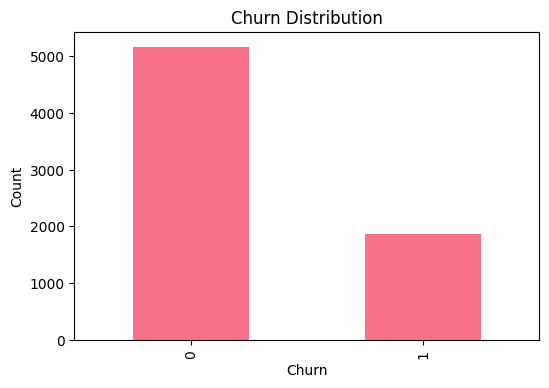

In [13]:
churn_rate = df['Churn'].mean()
churn_counts = df['Churn'].value_counts()
print(f"Overall churn rate: {churn_rate:.1%}")
print(f"Churn distribution: {churn_counts}")

# Quick visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

In [26]:
# Get all features except target
features = [col for col in df.columns if col != 'Churn']

# Calculate correlations with churn (only for numeric columns)
correlations = []
for feature in features:
    # Check if column is numeric
    if df[feature].dtype in ['int64', 'float64', 'bool']:
        try:
            corr = df[feature].corr(df['Churn'])
            if not pd.isna(corr):  # Skip if correlation is NaN
                correlations.append({
                    'feature': feature,
                    'correlation': abs(corr),  # Absolute value to see strength
                    'raw_correlation': corr
                })
        except:
            print(f"Skipping {feature} - couldn't calculate correlation")
    else:
        print(f"Skipping {feature} - not numeric (type: {df[feature].dtype})")

# Sort by correlation strength
corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)

print("TOP 10 FEATURES BY CORRELATION WITH CHURN:")
print("-" * 50)
for i, row in corr_df.head(10).iterrows():
    direction = "↑" if row['raw_correlation'] > 0 else "↓"
    print(f"{row['feature']:<30} {direction} {row['correlation']:.3f}")

print(f"\nThese are your top features to analyze next.")

Skipping tenure_group - not numeric (type: category)
Skipping Contract_Type - not numeric (type: object)
TOP 10 FEATURES BY CORRELATION WITH CHURN:
--------------------------------------------------
tenure                         ↓ 0.352
InternetService_Fiber optic    ↑ 0.308
Contract_Two year              ↓ 0.302
PaymentMethod_Electronic check ↑ 0.302
InternetService_No             ↓ 0.228
OnlineSecurity_No internet service ↓ 0.228
DeviceProtection_No internet service ↓ 0.228
TechSupport_No internet service ↓ 0.228
StreamingMovies_No internet service ↓ 0.228
StreamingTV_No internet service ↓ 0.228

These are your top features to analyze next.


In [16]:
# Churn rate by tenure groups with clear labeling
df['tenure_group'] = pd.cut(df['tenure'], 
                           bins=[0, 6, 12, 24, 36, 72], 
                           labels=['0-6mo', '6-12mo', '1-2yr', '2-3yr', '3+yr'])

churn_by_tenure = df.groupby('tenure_group')['Churn'].agg(['count', 'sum', 'mean'])

# Rename columns to be clear
churn_by_tenure.columns = ['Total_Customers', 'Churned_Customers', 'Churn_Rate']

print("Churn analysis by customer tenure:")
print(churn_by_tenure.round(3))

Churn analysis by customer tenure:
              Total_Customers  Churned_Customers  Churn_Rate
tenure_group                                                
0-6mo                    1470                784       0.533
6-12mo                    705                253       0.359
1-2yr                    1024                294       0.287
2-3yr                     832                180       0.216
3+yr                     3001                358       0.119


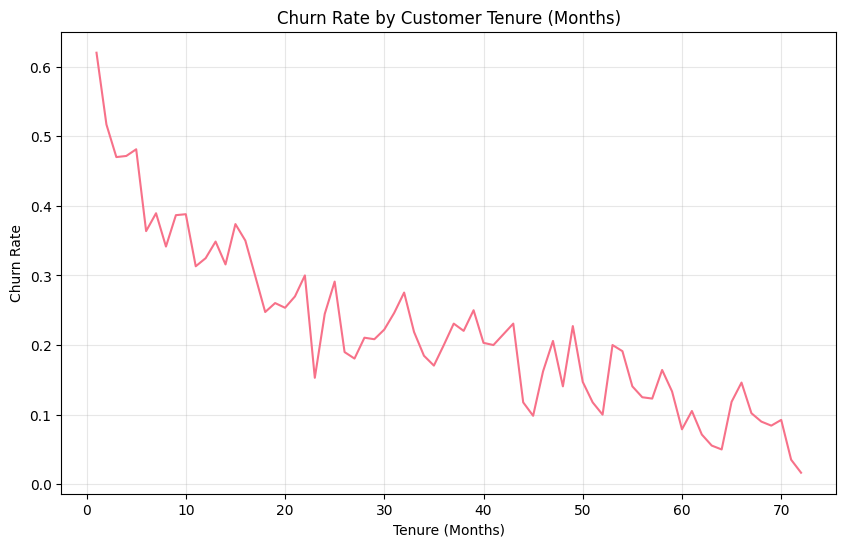

Tenure = 0 analysis:
Customers with 0 tenure: 11.0
Churn rate for 0 tenure: 0.000


In [17]:
# Plot churn rate by tenure (excluding tenure = 0)
plt.figure(figsize=(10, 6))

# Filter out tenure = 0 to avoid misleading spike
df_filtered = df[df['tenure'] > 0]
churn_by_tenure_month = df_filtered.groupby('tenure')['Churn'].mean()

plt.plot(churn_by_tenure_month.index, churn_by_tenure_month.values)
plt.title('Churn Rate by Customer Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate')
plt.grid(True, alpha=0.3)
plt.show()

# Also check what tenure = 0 looks like
print("Tenure = 0 analysis:")
tenure_zero = df[df['tenure'] == 0]['Churn'].agg(['count', 'mean'])
print(f"Customers with 0 tenure: {tenure_zero['count']}")
print(f"Churn rate for 0 tenure: {tenure_zero['mean']:.3f}")

Contract columns: ['Contract_One year', 'Contract_Two year']
Churn analysis by contract type:
                Total_Customers  Churn_Rate
Contract_Type                              
Month-to-month             3875       0.427
One year                   1473       0.113
Two year                   1695       0.028


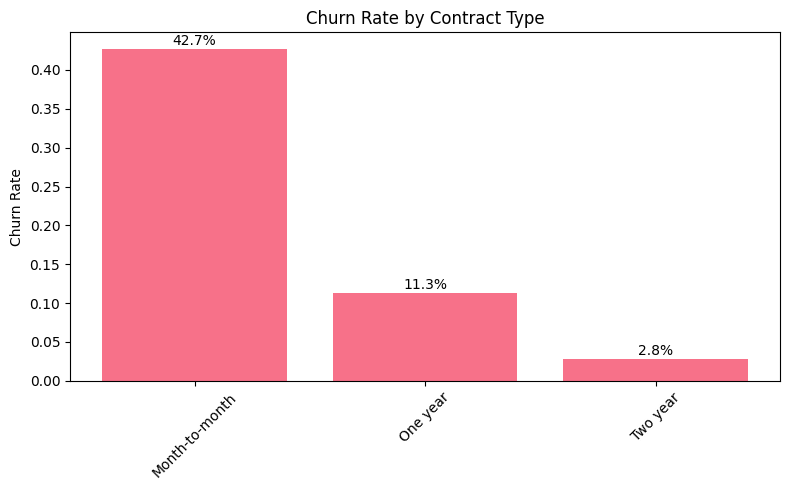

In [22]:
# Contract analysis with your actual columns
contract_cols = ['Contract_One year', 'Contract_Two year']
print("Contract columns:", contract_cols)

# Create a summary showing all contract types
# Remember: if both Contract_One year and Contract_Two year are 0, then it's Month-to-month
df['Contract_Type'] = 'Month-to-month'  # Default
df.loc[df['Contract_One year'] == 1, 'Contract_Type'] = 'One year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two year'

# Analyze churn by contract type
contract_analysis = df.groupby('Contract_Type')['Churn'].agg(['count', 'mean']).round(3)
contract_analysis.columns = ['Total_Customers', 'Churn_Rate']
print("Churn analysis by contract type:")
print(contract_analysis)

# Visualization
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract_Type')['Churn'].mean()
bars = plt.bar(contract_churn.index, contract_churn.values)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, contract_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{value:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# Print cols containing 'Internet'
import pandas 

In [ ]:
# Contract analysis with your actual columns
internet_cols = ['InternetService_Fiber optic    ↑ 0.308
', 'Contract_Two year']
print("Contract columns:", contract_cols)

# Create a summary showing all contract types
# Remember: if both Contract_One year and Contract_Two year are 0, then it's Month-to-month
df['Contract_Type'] = 'Month-to-month'  # Default
df.loc[df['Contract_One year'] == 1, 'Contract_Type'] = 'One year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two year'

# Analyze churn by contract type
contract_analysis = df.groupby('Contract_Type')['Churn'].agg(['count', 'mean']).round(3)
contract_analysis.columns = ['Total_Customers', 'Churn_Rate']
print("Churn analysis by contract type:")
print(contract_analysis)

# Visualization
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract_Type')['Churn'].mean()
bars = plt.bar(contract_churn.index, contract_churn.values)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, contract_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{value:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()